In [ ]:
import pathlib

import numpy as np
import pandas as pd
from plotnine import (
    aes,
    facet_wrap,
    geom_density,
    geom_vline,
    ggplot,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme_bw,
)
from plotnine.options import set_option


In [2]:
# Set figure directory
figure_dir = pathlib.Path("./figures")
figure_dir.mkdir(exist_ok=True)

In [3]:
# Load in annotated profiles from NF1 (with and without contamination)
nf1_contaminated = pd.read_parquet(
    "/media/18tbdrive/1.Github_Repositories/nf1_schwann_cell_painting_data/3.processing_features/data/converted_data/Plate_3.parquet"
)

nf1_not_contaminated = pd.read_parquet(
    "/media/18tbdrive/1.Github_Repositories/nf1_schwann_cell_painting_data/3.processing_features/data/converted_data/Plate_5.parquet"
)

In [4]:
# Load in cardiac fibrosis datasets (with and without contamination)
cf_contaminated = pd.read_parquet(
    "/home/jenna/targeted_fibrosis_mycoplasma_detection/3.preprocessing_features/data/converted_profiles/CARD-CelIns-CX7_250116110001_converted.parquet"
)

cf_normal = pd.read_parquet(
    "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_annotated.parquet"
)

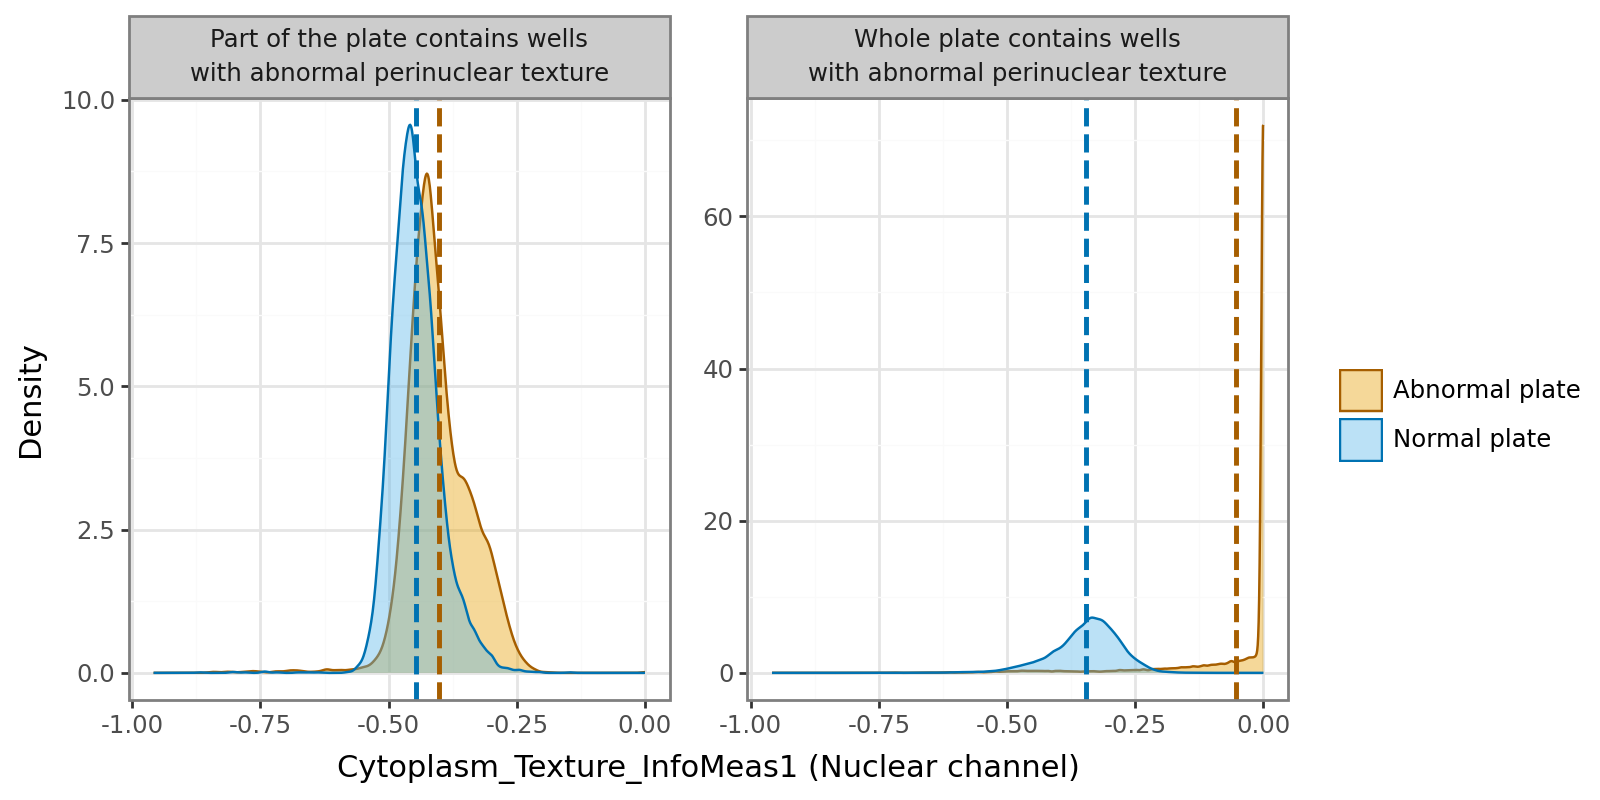

In [5]:
nf1_feature = "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256"
cf_feature = "Cytoplasm_Texture_InfoMeas1_Hoechst_3_02_256"

plot_df = pd.concat(
    [
        nf1_contaminated[[nf1_feature]]
        .rename(columns={nf1_feature: "feature_value"})
        .assign(
            dataset="Part of the plate contains wells\nwith abnormal perinuclear texture",
            status="Abnormal plate",
        ),
        nf1_not_contaminated[[nf1_feature]]
        .rename(columns={nf1_feature: "feature_value"})
        .assign(
            dataset="Part of the plate contains wells\nwith abnormal perinuclear texture",
            status="Normal plate",
        ),
        cf_contaminated[[cf_feature]]
        .rename(columns={cf_feature: "feature_value"})
        .assign(
            dataset="Whole plate contains wells\nwith abnormal perinuclear texture",
            status="Abnormal plate",
        ),
        cf_normal[[cf_feature]]
        .rename(columns={cf_feature: "feature_value"})
        .assign(
            dataset="Whole plate contains wells\nwith abnormal perinuclear texture",
            status="Normal plate",
        ),
    ],
    ignore_index=True,
)

# Means for each dataset/status combination
mean_df = plot_df.groupby(["dataset", "status"], as_index=False).agg(
    mean_value=("feature_value", "mean")
)

# Set the figure size
height = 4
width = 8
set_option("figure_size", (width, height))

p_dist = (
    ggplot(plot_df, aes(x="feature_value", fill="status", color="status"))
    + geom_density(alpha=0.4)
    + geom_vline(
        mean_df,
        aes(xintercept="mean_value", color="status"),
        linetype="dashed",
        size=1.0,
        show_legend=False,
    )
    + facet_wrap("~dataset", scales="free_y")
    + scale_fill_manual(
        values={
            "Normal plate": "#56B4E9",
            "Abnormal plate": "#E69F00",
        }
    )
    + scale_color_manual(
        values={
            "Normal plate": "#0072B2",  # darker blue for mean line
            "Abnormal plate": "#A65E00",  # darker orange for mean line
        }
    )
    + labs(
        x="Cytoplasm_Texture_InfoMeas1 (Nuclear channel)",
        y="Density",
        fill="",
        color="",
    )
    + theme_bw()
)

# Save the plot
p_dist.save(
    figure_dir / "contamination_cyto_feature_distributions.png",
    dpi=600,
    width=width,
    height=height,
    verbose=False,
)

p_dist.show()

In [ ]:
# Compute Bowley's skewness for each distribution
def _bowley_skewness(x: pd.Series) -> float:
    """Compute Bowley's skewness for a single group's feature values."""
    values = x["feature_value"].dropna()
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 50)
    q3 = np.percentile(values, 75)
    return (q3 + q1 - 2 * q2) / (q3 - q1)


bowley_skewness = plot_df.groupby(["dataset", "status"]).apply(_bowley_skewness)

print("Bowley's Skewness for each distribution:")
print(bowley_skewness)

Bowley's Skewness for each distribution:
dataset                                                              status        
Part of the plate contains wells\nwith abnormal perinuclear texture  Abnormal plate    0.244569
                                                                     Normal plate      0.082178
Whole plate contains wells\nwith abnormal perinuclear texture        Abnormal plate   -0.975608
                                                                     Normal plate     -0.081759
dtype: float64


/tmp/ipykernel_1885466/2429540578.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
